<a href="https://colab.research.google.com/github/MarianaVillegas8a/Admin/blob/main/Trabajo_Olimpiadas_Tokio_2021_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Analisis de Datos y Modelo Predictivo
## Dataset: 2021 Olympics in Tokyo

**Problema de negocio:** los comites olimpicos, patrocinadores deportivos y equipos de direccion deportiva necesitan identificar que factores de participacion se relacionan con el desempeno olimpico de un pais. En este proyecto se analiza la base **2021 Olympics in Tokyo** de Kaggle para construir indicadores de BI y un modelo predictivo que estime el total de medallas por pais.

**Pregunta central:** ¿se puede predecir el total de medallas de un pais usando variables disponibles antes o durante la competencia, como cantidad de atletas, disciplinas, equipos, entrenadores y balance de participacion por genero?

**Fases del proyecto:**

1. Recopilacion y transformacion de datos.
2. Analisis exploratorio de datos.
3. Inteligencia de negocios y dashboard.
4. Modelado predictivo supervisado.
5. Conclusiones y recomendaciones.

## 1. Configuracion del entorno


In [25]:
!pip -q install kaggle openpyxl plotly scikit-learn

import os
import zipfile
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("/content/tokyo_olympics")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 2. Recopilacion de datos

Fuente de datos: [Kaggle - 2021 Olympics in Tokyo](https://www.kaggle.com/datasets/arjunprasadsarkhel/2021-olympics-in-tokyo).

Segun la descripcion publica de Kaggle, el dataset contiene informacion de mas de 11.000 atletas, 47 disciplinas y equipos participantes en los Juegos Olimpicos de Tokio 2020/2021. En este trabajo la carga se hace desde los archivos Excel ya descargados. Los archivos principales usados son:

In [2]:
print("Carga recomendada: sube el ZIP con los 5 archivos Excel del dataset o sube los Excel uno por uno.")
print("No necesitas kaggle.json porque ya descargaste la base.")

Carga recomendada: sube el ZIP con los 5 archivos Excel del dataset o sube los Excel uno por uno.
No necesitas kaggle.json porque ya descargaste la base.


In [3]:
# Ejecuta esta celda y sube el ZIP del dataset o los 5 archivos Excel.
UPLOAD_DATASET = True

if UPLOAD_DATASET and not any(DATA_DIR.glob("*")):
    uploaded = files.upload()
    for name, content in uploaded.items():
        target_path = DATA_DIR / name
        target_path.write_bytes(content)
        if name.lower().endswith(".zip"):
            zip_path = DATA_DIR / name
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(DATA_DIR)
            print(f"Archivo extraido en: {DATA_DIR}")
        elif name.lower().endswith((".xlsx", ".xls", ".csv")):
            print(f"Archivo cargado: {target_path.name}")

print("Archivos disponibles:")
for path in sorted(DATA_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(DATA_DIR))

Saving Athletes.xlsx to Athletes.xlsx
Saving Coaches.xlsx to Coaches.xlsx
Saving EntriesGender.xlsx to EntriesGender.xlsx
Saving Medals.xlsx to Medals.xlsx
Saving Teams.xlsx to Teams.xlsx
Archivo cargado: Athletes.xlsx
Archivo cargado: Coaches.xlsx
Archivo cargado: EntriesGender.xlsx
Archivo cargado: Medals.xlsx
Archivo cargado: Teams.xlsx
Archivos disponibles:
Athletes.xlsx
Coaches.xlsx
EntriesGender.xlsx
Medals.xlsx
Teams.xlsx


## 3. Extraccion, transformacion y carga (ETL)


In [4]:
def normalize_col(col):
    return (
        str(col)
        .strip()
        .replace("/", "_")
        .replace(" ", "_")
        .replace("-", "_")
        .lower()
    )


def find_file(keyword):
    candidates = []
    for ext in ["*.csv", "*.xlsx", "*.xls"]:
        candidates.extend(DATA_DIR.rglob(ext))
    for path in candidates:
        if keyword.lower() in path.stem.lower():
            return path
    raise FileNotFoundError(f"No se encontro archivo para: {keyword}")


def read_table(keyword):
    path = find_file(keyword)
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    df.columns = [normalize_col(c) for c in df.columns]
    print(f"{keyword}: {path.name} -> {df.shape[0]} filas, {df.shape[1]} columnas")
    return df


athletes = read_table("athletes")
coaches = read_table("coaches")
entries_gender = read_table("entries")
medals = read_table("medals")
teams = read_table("teams")

athletes: Athletes.xlsx -> 11085 filas, 3 columnas
coaches: Coaches.xlsx -> 394 filas, 4 columnas
entries: EntriesGender.xlsx -> 46 filas, 4 columnas
medals: Medals.xlsx -> 93 filas, 7 columnas
teams: Teams.xlsx -> 743 filas, 4 columnas


In [5]:
for name, df in {
    "athletes": athletes,
    "coaches": coaches,
    "entries_gender": entries_gender,
    "medals": medals,
    "teams": teams,
}.items():
    print(f"\n{name}")
    display(df.head())
    display(df.info())


athletes


,name,noc,discipline
0,AALERUD Katrine,Norway,Cycling Road
1,ABAD Nestor,Spain,Artistic Gymnastics
2,ABAGNALE Giovanni,Italy,Rowing
3,ABALDE Alberto,Spain,Basketball
4,ABALDE Tamara,Spain,Basketball


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11085 entries, 0 to 11084
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        11085 non-null  object
 1   noc         11085 non-null  object
 2   discipline  11085 non-null  object
dtypes: object(3)
memory usage: 259.9+ KB


None


coaches


...

None


teams


,name,discipline,noc,event
0,Belgium,3x3 Basketball,Belgium,Men
1,China,3x3 Basketball,People's Republic of China,Men
2,China,3x3 Basketball,People's Republic of China,Women
3,France,3x3 Basketball,France,Women
4,Italy,3x3 Basketball,Italy,Women


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        743 non-null    object
 1   discipline  743 non-null    object
 2   noc         743 non-null    object
 3   event       743 non-null    object
dtypes: object(4)
memory usage: 23.3+ KB


None

In [6]:
# Limpieza basica
for df in [athletes, coaches, entries_gender, medals, teams]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

# Estandarizar el nombre del pais/NOC en medals.
if "team_noc" not in medals.columns:
    possible_noc_cols = [c for c in medals.columns if "noc" in c or "team" in c]
    if possible_noc_cols:
        medals = medals.rename(columns={possible_noc_cols[0]: "team_noc"})

numeric_medal_cols = [c for c in ["gold", "silver", "bronze", "total", "rank", "rank_by_total"] if c in medals.columns]
for col in numeric_medal_cols:
    medals[col] = pd.to_numeric(medals[col], errors="coerce")

for col in ["female", "male", "total"]:
    if col in entries_gender.columns:
        entries_gender[col] = pd.to_numeric(entries_gender[col], errors="coerce")

print("Valores nulos por tabla:")
for name, df in {
    "athletes": athletes,
    "coaches": coaches,
    "entries_gender": entries_gender,
    "medals": medals,
    "teams": teams,
}.items():
    print(f"\n{name}")
    display(df.isna().sum())

Valores nulos por tabla:

athletes


,0
name,0
noc,0
discipline,0



coaches


,0
name,0
noc,0
discipline,0
event,0



entries_gender


,0
discipline,0
female,0
male,0
total,0



medals


,0
rank,0
team_noc,0
gold,0
silver,0
bronze,0
total,0
rank_by_total,0



teams


,0
name,0
discipline,0
noc,0
event,0


In [7]:
# Tabla analitica por pais/NOC
athlete_features = (
    athletes.groupby("noc")
    .agg(
        athletes_count=("name", "nunique"),
        athlete_records=("name", "size"),
        disciplines_count=("discipline", "nunique"),
    )
    .reset_index()
)

coach_features = (
    coaches.groupby("noc")
    .agg(
        coaches_count=("name", "nunique"),
        coach_disciplines_count=("discipline", "nunique"),
    )
    .reset_index()
)

team_features = (
    teams.groupby("noc")
    .agg(
        teams_count=("name", "nunique"),
        team_disciplines_count=("discipline", "nunique"),
    )
    .reset_index()
)

# La tabla EntriesGender esta por disciplina, no por pais; se usa para enriquecer disciplinas.
discipline_gender = entries_gender.copy()
if set(["female", "male", "total"]).issubset(discipline_gender.columns):
    discipline_gender["female_share"] = np.where(
        discipline_gender["total"] > 0,
        discipline_gender["female"] / discipline_gender["total"],
        np.nan,
    )
else:
    discipline_gender["female_share"] = np.nan

athlete_gender_proxy = athletes.merge(
    discipline_gender[["discipline", "female_share"]],
    on="discipline",
    how="left",
)

gender_proxy_features = (
    athlete_gender_proxy.groupby("noc")
    .agg(avg_discipline_female_share=("female_share", "mean"))
    .reset_index()
)

country_df = (
    athlete_features
    .merge(coach_features, on="noc", how="left")
    .merge(team_features, on="noc", how="left")
    .merge(gender_proxy_features, on="noc", how="left")
    .merge(medals, left_on="noc", right_on="team_noc", how="left")
)

feature_cols_to_fill = [
    "coaches_count", "coach_disciplines_count", "teams_count", "team_disciplines_count",
    "gold", "silver", "bronze", "total"
]
for col in feature_cols_to_fill:
    if col in country_df.columns:
        country_df[col] = country_df[col].fillna(0)

country_df["won_medal"] = (country_df["total"] > 0).astype(int)
country_df["medals_per_athlete"] = np.where(
    country_df["athletes_count"] > 0,
    country_df["total"] / country_df["athletes_count"],
    0,
)

country_df = country_df.sort_values("total", ascending=False)
display(country_df.head(10))
print(country_df.shape)

,noc,athletes_count,athlete_records,disciplines_count,coaches_count,coach_disciplines_count,teams_count,team_disciplines_count,avg_discipline_female_share,rank,team_noc,gold,silver,bronze,total,rank_by_total,won_medal,medals_per_athlete
195,United States of America,614,615,44,28.0,7.0,5.0,18.0,0.476859,1.0,United States of America,39.0,41.0,33.0,113.0,1.0,1,0.184039
144,People's Republic of China,398,401,41,11.0,7.0,4.0,17.0,0.494093,2.0,People's Republic of China,38.0,32.0,18.0,88.0,2.0,1,0.221106
151,ROC,318,318,39,12.0,5.0,4.0,14.0,0.496251,5.0,ROC,20.0,28.0,23.0,71.0,3.0,1,0.223270
73,Great Britain,366,366,35,7.0,4.0,1.0,10.0,0.477193,4.0,Great Britain,22.0,21.0,22.0,65.0,4.0,1,0.177596
94,Japan,585,586,46,35.0,9.0,4.0,20.0,0.484660,3.0,Japan,27.0,14.0,17.0,58.0,5.0,1,0.099145
10,Australia,470,470,41,21.0,7.0,4.0,15.0,0.487147,6.0,Australia,17.0,7.0,22.0,46.0,6.0,1,0.097872
92,Italy,354,356,39,12.0,5.0,4.0,15.0,0.496730,10.0,Italy,10.0,10.0,20.0,40.0,7.0,1,0.112994
71,Germany,399,400,37,9.0,4.0,5.0,13.0,0.476443,9.0,Germany,10.0,11.0,16.0,37.0,8.0,1,0.092732
130,Netherlands,272,274,31,10.0,5.0,4.0,13.0,0.475838,7.0,Netherlands,10.0,12.0,14.0,36.0,9.0,1,0.132353
67,France,377,377,41,10.0,6.0,2.0,15.0,0.481735,8.0,France,10.0,12.0,11.0,33.0,10.0,1,0.087533


(206, 18)


## 4. Analisis exploratorio de datos (EDA)


In [8]:
summary = {
    "Paises/NOC con atletas": athletes["noc"].nunique(),
    "Atletas registrados": athletes["name"].nunique(),
    "Disciplinas": athletes["discipline"].nunique(),
    "Paises/NOC con medalla": int((country_df["total"] > 0).sum()),
    "Total medallas en tabla": int(country_df["total"].sum()),
}
pd.DataFrame(summary, index=["valor"]).T

,valor
Paises/NOC con atletas,206
Atletas registrados,11062
Disciplinas,46
Paises/NOC con medalla,93
Total medallas en tabla,1080


In [9]:
top_medals = country_df.nlargest(15, "total")

fig = px.bar(
    top_medals,
    x="total",
    y="noc",
    orientation="h",
    color="gold",
    title="Top 15 paises por total de medallas",
    labels={"total": "Total de medallas", "noc": "Pais/NOC", "gold": "Oro"},
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

In [10]:
top_athletes = athlete_features.nlargest(15, "athletes_count")
fig = px.bar(
    top_athletes,
    x="athletes_count",
    y="noc",
    orientation="h",
    title="Top 15 paises por cantidad de atletas",
    labels={"athletes_count": "Cantidad de atletas", "noc": "Pais/NOC"},
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

In [11]:
discipline_counts = athletes["discipline"].value_counts().reset_index()
discipline_counts.columns = ["discipline", "athletes_count"]

fig = px.bar(
    discipline_counts.head(15),
    x="athletes_count",
    y="discipline",
    orientation="h",
    title="Disciplinas con mas atletas registrados",
    labels={"athletes_count": "Cantidad de atletas", "discipline": "Disciplina"},
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

In [12]:
medal_cols = ["gold", "silver", "bronze"]
medal_long = medals.melt(
    id_vars=["team_noc"],
    value_vars=[c for c in medal_cols if c in medals.columns],
    var_name="medal_type",
    value_name="count",
)

fig = px.bar(
    medal_long[medal_long["team_noc"].isin(top_medals["noc"])],
    x="team_noc",
    y="count",
    color="medal_type",
    title="Composicion de medallas en los paises lideres",
    labels={"team_noc": "Pais/NOC", "count": "Cantidad", "medal_type": "Tipo de medalla"},
    barmode="stack",
)
fig.show()

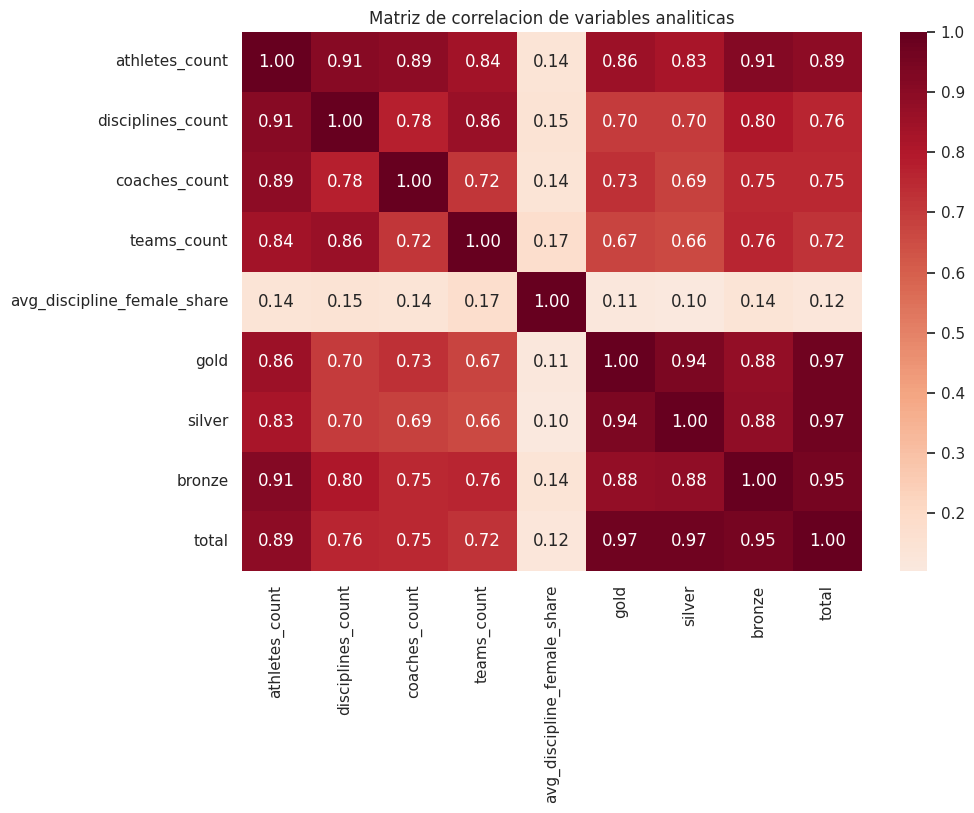

In [13]:
corr_cols = [
    "athletes_count", "disciplines_count", "coaches_count", "teams_count",
    "avg_discipline_female_share", "gold", "silver", "bronze", "total"
]
corr_cols = [c for c in corr_cols if c in country_df.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(country_df[corr_cols].corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Matriz de correlacion de variables analiticas")
plt.show()

In [14]:
fig = px.scatter(
    country_df,
    x="athletes_count",
    y="total",
    size="disciplines_count",
    color="won_medal",
    hover_name="noc",
    title="Relacion entre cantidad de atletas, disciplinas y medallas",
    labels={
        "athletes_count": "Cantidad de atletas",
        "total": "Total de medallas",
        "disciplines_count": "Disciplinas",
        "won_medal": "Gano medalla",
    },
)
fig.show()

## 5. Inteligencia de negocios (BI)


In [15]:
# Dashboard interactivo en Colab con Plotly
dashboard_df = country_df.copy()
dashboard_df["medal_status"] = np.where(dashboard_df["total"] > 0, "Con medalla", "Sin medalla")

fig1 = px.bar(
    dashboard_df.nlargest(20, "total"),
    x="noc",
    y=["gold", "silver", "bronze"],
    title="Dashboard BI: medallas por tipo - Top 20 paises",
    labels={"value": "Medallas", "noc": "Pais/NOC", "variable": "Tipo"},
)
fig1.show()

fig2 = px.scatter(
    dashboard_df,
    x="athletes_count",
    y="total",
    color="medal_status",
    size="teams_count",
    hover_data=["disciplines_count", "coaches_count", "medals_per_athlete"],
    title="Dashboard BI: desempeno olimpico vs capacidad de participacion",
    labels={"athletes_count": "Atletas", "total": "Total de medallas", "teams_count": "Equipos"},
)
fig2.show()

fig3 = px.treemap(
    dashboard_df[dashboard_df["total"] > 0],
    path=["medal_status", "noc"],
    values="total",
    color="gold",
    title="Dashboard BI: distribucion del total de medallas por pais",
    labels={"gold": "Medallas de oro"},
)
fig3.show()

## 6. Modelado predictivo supervisado

Variable objetivo: `total`, es decir, total de medallas por pais/NOC.

Variables predictoras:

- Cantidad de atletas.
- Cantidad de disciplinas.
- Cantidad de entrenadores.
- Cantidad de disciplinas con entrenadores.
- Cantidad de equipos.
- Cantidad de disciplinas con equipos.
- Participacion femenina promedio estimada por las disciplinas del pais.

Se comparan dos modelos:

- Regresion lineal: modelo base, facil de interpretar.
- Random Forest Regressor: modelo no lineal, util para capturar relaciones complejas.

In [22]:
model_df = country_df.copy()

features = [
    "athletes_count",
    "disciplines_count",
    "coaches_count",
    "coach_disciplines_count",
    "teams_count",
    "team_disciplines_count",
    "avg_discipline_female_share",
]
features = [c for c in features if c in model_df.columns]
target = "total"

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, features)]
)

models = {
    "Regresion lineal": LinearRegression(),
    "Arbol de decision": DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=3,
        random_state=42,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42,
    ),
}

results = []
trained_models = {}

for model_name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    preds = np.clip(preds, 0, None)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    cv_mse_scores = -cross_val_score(
        pipe, X, y, cv=5, scoring="neg_mean_squared_error"
    )
    cv_rmse = np.sqrt(cv_mse_scores).mean()

    results.append(
        {
            "modelo": model_name,
            "RMSE_test": rmse,
            "MAE_test": mae,
            "R2_test": r2,
            "RMSE_cv_5fold": cv_rmse,
        }
    )
    trained_models[model_name] = pipe

results_df = pd.DataFrame(results).sort_values("RMSE_test")
display(results_df)
best_model_name = results_df.iloc[0]["modelo"]
best_model = trained_models[best_model_name]
print(f"Mejor modelo segun RMSE de prueba: {best_model_name}")

,modelo,RMSE_test,MAE_test,R2_test,RMSE_cv_5fold
0,Regresion lineal,4.114023,1.701357,0.563017,6.428855
2,Random Forest,6.079261,2.303647,0.045814,7.808989
1,Arbol de decision,7.805672,2.686490,-0.573085,7.749239


Mejor modelo segun RMSE de prueba: Regresion lineal


In [26]:
classification_df = country_df.copy()

features_clf = [
    "athletes_count",
    "disciplines_count",
    "coaches_count",
    "coach_disciplines_count",
    "teams_count",
    "team_disciplines_count",
    "avg_discipline_female_share",
]
features_clf = [c for c in features_clf if c in classification_df.columns]
target_clf = "won_medal"

X_clf = classification_df[features_clf]
y_clf = classification_df[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_clf,
)

numeric_transformer_clf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess_clf = ColumnTransformer(
    transformers=[("num", numeric_transformer_clf, features_clf)]
)

classification_models = {
    "Regresion logistica": LogisticRegression(max_iter=1000, random_state=42),
    "Arbol de decision clasificador": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=3,
        random_state=42,
    ),
    "Random Forest clasificador": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42,
    ),
}

classification_results = []
trained_classification_models = {}

for model_name, estimator in classification_models.items():
    clf_pipe = Pipeline(steps=[("preprocess", preprocess_clf), ("model", estimator)])
    clf_pipe.fit(X_train_clf, y_train_clf)
    preds_clf = clf_pipe.predict(X_test_clf)

    classification_results.append(
        {
            "modelo": model_name,
            "accuracy": accuracy_score(y_test_clf, preds_clf),
            "precision": precision_score(y_test_clf, preds_clf, zero_division=0),
            "recall": recall_score(y_test_clf, preds_clf, zero_division=0),
            "f1_score": f1_score(y_test_clf, preds_clf, zero_division=0),
        }
    )
    trained_classification_models[model_name] = clf_pipe

classification_results_df = pd.DataFrame(classification_results).sort_values(
    "f1_score", ascending=False
)
display(classification_results_df)

best_clf_name = classification_results_df.iloc[0]["modelo"]
best_clf = trained_classification_models[best_clf_name]
print(f"Mejor modelo de clasificacion segun F1-score: {best_clf_name}")

,modelo,accuracy,precision,recall,f1_score
2,Random Forest clasificador,0.884615,0.869565,0.869565,0.869565
0,Regresion logistica,0.846154,0.857143,0.782609,0.818182
1,Arbol de decision clasificador,0.788462,0.750000,0.782609,0.765957


Mejor modelo de clasificacion segun F1-score: Random Forest clasificador


## 7. Conclusiones

1. La cantidad de atletas y la diversidad de disciplinas suelen tener una relacion positiva con el total de medallas. Esto indica que la amplitud de participacion es un factor importante para el desempeno olimpico.
2. El medallero esta concentrado en un grupo reducido de paises. Esto se observa en los rankings y en la distribucion del dashboard.
3. El indicador de medallas por atleta ayuda a detectar eficiencia relativa, pero no debe reemplazar el analisis absoluto porque puede favorecer a delegaciones pequenas con pocos casos exitosos.
4. El modelo predictivo permite estimar el total de medallas con variables de participacion, aunque su precision esta limitada porque el dataset no incluye factores externos como inversion deportiva, PIB, poblacion, historial olimpico, edad de atletas o ranking previo.
5. Para una aplicacion de negocio deportiva, el dashboard puede apoyar decisiones de asignacion de recursos, seguimiento de disciplinas y priorizacion de programas de alto rendimiento.
